# REKSA AI v2 — Leakage-Safe Training on Continuous Synthetic Trajectories

Notebook ini melatih dua AI REKSA dengan kontrak yang lebih ketat:

1. **Pre-Danger / Near-Miss Risk Forecaster** — memakai data hanya sampai waktu `t` untuk memprediksi onset bahaya yang punya precursor terukur (proximity, air-quality, motion-near-hazard) pada `(t, t+3s]`.
2. **AI Priority Engine** — mengurutkan event menjadi `LOW`, `MEDIUM`, atau `HIGH`; label sintetis dibuat menyerupai proses dua reviewer + adjudikasi.

Perubahan utama dari dataset v1: overlapping windows berasal dari trajectory kontinu; target masa depan memiliki lead time eksplisit; kolom target/reviewer/scenario dilarang menjadi fitur; missing telemetry kecil sengaja dipertahankan; test holdout menggunakan participant yang tidak pernah terlihat saat training.

`FALL_CANDIDATE` dan `IMPACT_CANDIDATE` **bukan target forecasting** jika terjadi spontan tanpa precursor. MPU6050 tetap mendeteksi kandidat jatuh/benturan ketika event terjadi, lalu event tersebut masuk ke Priority Engine. Ini sengaja untuk menghindari klaim bahwa REKSA dapat "meramal" jatuh yang tidak memiliki sinyal pendahulu.

> **Batas klaim:** seluruh data masih sintetis. Metrik notebook membuktikan pipeline dan desain eksperimen, bukan performa keselamatan dunia nyata. Alarm deterministik ESP32 tetap menjadi safety layer utama.

## 1. Setup dan loading data

In [ ]:
from pathlib import Path
import json, platform, warnings
from datetime import UTC, datetime

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn

from sklearn.base import clone
from sklearn.calibration import CalibratedClassifierCV
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, average_precision_score, brier_score_loss,
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    f1_score, fbeta_score, make_scorer, precision_recall_curve,
    precision_score, recall_score, roc_auc_score,
)
from sklearn.model_selection import GroupShuffleSplit, StratifiedGroupKFold, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

SEED = 20260807
np.random.seed(SEED)
sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", 100)

print("Python:", platform.python_version())
print("pandas:", pd.__version__)
print("scikit-learn:", sklearn.__version__)

Python: 3.12.13
pandas: 2.2.2
scikit-learn: 1.6.1


In [ ]:
def locate_data_dir() -> Path:
    candidates = [Path.cwd(), Path('/content'), Path.cwd() / 'output/reksa_ai_v2']
    for path in candidates:
        if (path / 'forecasting_windows_realistic_v2.csv').exists() and (path / 'event_dataset_realistic_v2.csv').exists():
            return path
    raise FileNotFoundError('Place both REKSA v2 CSV files beside the notebook or in /content/.')

DATA_DIR = locate_data_dir()
MODEL_DIR = DATA_DIR / 'models_v2'
MODEL_DIR.mkdir(parents=True, exist_ok=True)

forecast_raw = pd.read_csv(DATA_DIR / 'forecasting_windows_realistic_v2.csv')
priority_raw = pd.read_csv(DATA_DIR / 'event_dataset_realistic_v2.csv')
print('DATA_DIR:', DATA_DIR)
print('Forecast shape:', forecast_raw.shape)
print('Priority shape:', priority_raw.shape)

DATA_DIR: /content
Forecast shape: (13841, 51)
Priority shape: (6000, 47)


## 2. Feature contract dan leakage guard

In [ ]:
FORECAST_NUMERIC = [
    'window_duration_seconds', 'forecast_horizon_seconds', 'rssi_valid_ratio',
    'rssi_mean_dbm', 'rssi_peak_dbm', 'rssi_min_dbm', 'rssi_std_db',
    'rssi_slope_dbm_per_s', 'rssi_last_dbm', 'beacon_age_seconds',
    'packet_loss_ratio', 'acceleration_mean_g', 'acceleration_max_g',
    'acceleration_energy', 'jerk_max_g_per_s', 'gyroscope_mean_dps',
    'gyroscope_max_dps', 'gyroscope_energy', 'orientation_change_deg',
    'stillness_ratio', 'sudden_motion', 'temperature_c', 'humidity_percent',
    'mq135_relative_change_pct', 'hazard_active_now',
    'current_warning_duration_seconds', 'repeated_exposure_count',
]
FORECAST_CATEGORICAL = ['current_state', 'sensor_health_status', 'hazard_type']
FORECAST_FEATURES = FORECAST_NUMERIC + FORECAST_CATEGORICAL
FORECAST_TARGET = 'danger_onset_within_horizon'

PRIORITY_NUMERIC = [
    'event_duration_seconds', 'rssi_mean_dbm', 'rssi_peak_dbm', 'rssi_min_dbm',
    'rssi_std_db', 'rssi_slope_dbm_per_s', 'packet_loss_ratio',
    'warning_duration_seconds', 'danger_duration_seconds', 'state_transition_count',
    'acceleration_max_g', 'gyroscope_max_dps', 'orientation_change_deg',
    'sudden_motion', 'candidate_impact', 'candidate_fall',
    'post_event_stillness_seconds', 'temperature_c', 'humidity_percent',
    'mq135_relative_change_pct', 'mq135_warmed_up', 'hazard_active',
    'local_warning_success', 'repeated_exposure_count', 'similar_event_count',
]
PRIORITY_CATEGORICAL = ['hazard_type', 'alarm_level', 'connectivity_status', 'sensor_health_status']
PRIORITY_FEATURES = PRIORITY_NUMERIC + PRIORITY_CATEGORICAL
PRIORITY_TARGET = 'supervisor_priority'

FORBIDDEN = {
    'row_index','window_id','event_id','participant_id','session_id','site_id','recording_date',
    'scenario_id','trajectory_id','sequence_no','worker_id','helmet_id','hazard_id',
    'window_started_at','window_ended_at','occurred_at','time_to_danger_seconds',
    'future_danger_reason','target_source','reviewer_a_priority','reviewer_b_priority',
    'review_agreement','label_confidence','verification_label','label_source','data_origin',
    FORECAST_TARGET, PRIORITY_TARGET,
}
assert not set(FORECAST_FEATURES) & FORBIDDEN
assert not set(PRIORITY_FEATURES) & FORBIDDEN
print('Leakage guard: PASS')
print('Forecast features:', len(FORECAST_FEATURES), 'Priority features:', len(PRIORITY_FEATURES))

Leakage guard: PASS
Forecast features: 30 Priority features: 29


## 3. Audit temporal, missing telemetry, dan distribusi label

In [ ]:
forecast_df = forecast_raw.copy()
priority_df = priority_raw.copy()

for col in ['sudden_motion','hazard_active_now']:
    forecast_df[col] = forecast_df[col].astype(int)
for col in ['sudden_motion','candidate_impact','candidate_fall','mq135_warmed_up','hazard_active','local_warning_success']:
    priority_df[col] = priority_df[col].astype(int)

forecast_df['window_started_at'] = pd.to_datetime(forecast_df['window_started_at'], utc=True)
forecast_df['window_ended_at'] = pd.to_datetime(forecast_df['window_ended_at'], utc=True)
priority_df['occurred_at'] = pd.to_datetime(priority_df['occurred_at'], utc=True)

assert forecast_df.window_id.is_unique and priority_df.event_id.is_unique
positive = forecast_df[FORECAST_TARGET].eq(1)
assert (forecast_df.loc[positive, 'time_to_danger_seconds'] > 0).all()
assert (forecast_df.loc[positive, 'time_to_danger_seconds'] <= forecast_df.loc[positive, 'forecast_horizon_seconds']).all()
assert not forecast_df.current_state.eq('DANGER').any(), 'Forecast input must stop before DANGER.'
assert ((forecast_df.rssi_min_dbm <= forecast_df.rssi_mean_dbm) & (forecast_df.rssi_mean_dbm <= forecast_df.rssi_peak_dbm)).fillna(True).all()
assert ((priority_df.rssi_min_dbm <= priority_df.rssi_mean_dbm) & (priority_df.rssi_mean_dbm <= priority_df.rssi_peak_dbm)).all()
assert (priority_df.warning_duration_seconds + priority_df.danger_duration_seconds <= priority_df.event_duration_seconds + 1e-9).all()

print('Forecast positive prevalence:', round(forecast_df[FORECAST_TARGET].mean(), 4))
print('Priority prevalence:')
display(priority_df[PRIORITY_TARGET].value_counts(normalize=True).rename('proportion').to_frame())
print('Forecast feature missing cells:', int(forecast_df[FORECAST_FEATURES].isna().sum().sum()))
print('Priority feature missing cells:', int(priority_df[PRIORITY_FEATURES].isna().sum().sum()))
print('Priority reviewer agreement:', round(priority_df.review_agreement.mean(), 4))

Forecast positive prevalence: 0.0566
Priority prevalence:


,proportion
supervisor_priority,
LOW,0.512667
MEDIUM,0.413333
HIGH,0.074000


Forecast feature missing cells: 497
Priority feature missing cells: 488
Priority reviewer agreement: 0.7787


,feature,adjacent_window_correlation
0,rssi_mean_dbm,0.945481
1,rssi_peak_dbm,0.921650
2,acceleration_max_g,0.699889
3,gyroscope_max_dps,0.715952
4,temperature_c,0.999184
5,mq135_relative_change_pct,0.969256


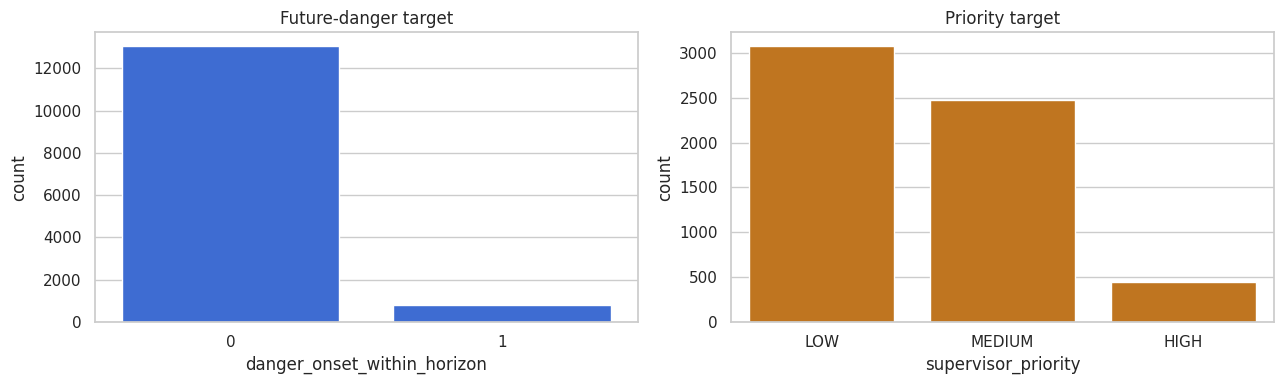

In [ ]:
# Continuity audit: overlapping windows should remain correlated because they share raw trajectory samples.
ordered = forecast_df.sort_values(['trajectory_id','window_ended_at']).copy()
grouped = ordered.groupby('trajectory_id', sort=False)
continuity_rows = []
for feature in ['rssi_mean_dbm','rssi_peak_dbm','acceleration_max_g','gyroscope_max_dps','temperature_c','mq135_relative_change_pct']:
    next_value = grouped[feature].shift(-1)
    valid = ordered[feature].notna() & next_value.notna()
    continuity_rows.append({'feature': feature, 'adjacent_window_correlation': ordered.loc[valid,feature].corr(next_value[valid])})
continuity = pd.DataFrame(continuity_rows)
display(continuity)

fig, axes = plt.subplots(1,2,figsize=(13,4))
sns.countplot(data=forecast_df, x=FORECAST_TARGET, ax=axes[0], color='#2563EB')
axes[0].set_title('Future-danger target')
sns.countplot(data=priority_df, x=PRIORITY_TARGET, order=['LOW','MEDIUM','HIGH'], ax=axes[1], color='#D97706')
axes[1].set_title('Priority target')
plt.tight_layout(); plt.show()

## 4. Grouped splitting dan preprocessing

In [ ]:
def group_holdout(frame, target, test_size=0.25, seed=SEED):
    groups = frame['participant_id'].astype(str)
    splitter = GroupShuffleSplit(n_splits=1, test_size=test_size, random_state=seed)
    tr, te = next(splitter.split(frame, frame[target], groups))
    train, test = frame.iloc[tr].reset_index(drop=True), frame.iloc[te].reset_index(drop=True)
    assert not (set(train.participant_id) & set(test.participant_id))
    return train, test

def make_preprocessor(numeric, categorical):
    numeric_pipe = Pipeline([
        ('imputer', SimpleImputer(strategy='median', add_indicator=True)),
        ('scaler', StandardScaler()),
    ])
    categorical_pipe = Pipeline([
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('onehot', OneHotEncoder(handle_unknown='ignore')),
    ])
    return ColumnTransformer([('numeric', numeric_pipe, numeric), ('categorical', categorical_pipe, categorical)])

def candidates(numeric, categorical):
    return {
        'logistic_regression': Pipeline([
            ('preprocess', make_preprocessor(numeric,categorical)),
            ('classifier', LogisticRegression(max_iter=2500,class_weight='balanced',random_state=SEED)),
        ]),
        'random_forest': Pipeline([
            ('preprocess', make_preprocessor(numeric,categorical)),
            ('classifier', RandomForestClassifier(n_estimators=180,min_samples_leaf=4,max_features='sqrt',class_weight='balanced_subsample',random_state=SEED,n_jobs=-1)),
        ]),
    }

def binary_metrics(y, prob, threshold):
    pred = (np.asarray(prob) >= threshold).astype(int)
    return {
        'threshold': threshold,
        'precision': precision_score(y,pred,zero_division=0),
        'recall': recall_score(y,pred,zero_division=0),
        'f2': fbeta_score(y,pred,beta=2,zero_division=0),
        'f1': f1_score(y,pred,zero_division=0),
        'roc_auc': roc_auc_score(y,prob),
        'average_precision': average_precision_score(y,prob),
        'brier_score': brier_score_loss(y,prob),
        'confusion_matrix': confusion_matrix(y,pred,labels=[0,1]).tolist(),
    }

def tune_threshold(y, prob, precision_floor=0.20):
    rows=[]
    for threshold in np.linspace(0.05,0.90,172):
        pred=(np.asarray(prob)>=threshold).astype(int)
        rows.append((threshold,precision_score(y,pred,zero_division=0),recall_score(y,pred,zero_division=0),fbeta_score(y,pred,beta=2,zero_division=0)))
    table=pd.DataFrame(rows,columns=['threshold','precision','recall','f2'])
    eligible=table[table.precision>=precision_floor]
    selected=(eligible if len(eligible) else table).sort_values(['f2','recall'],ascending=False).iloc[0]
    return float(selected.threshold), table

# Part A — Pre-Danger Forecaster

## A1. Participant holdout, model selection, dan threshold validation

In [ ]:
forecast_train_all, forecast_test = group_holdout(forecast_df, FORECAST_TARGET, test_size=0.25, seed=SEED)
forecast_fit, forecast_val = group_holdout(forecast_train_all, FORECAST_TARGET, test_size=0.22, seed=SEED+17)

Xf_fit, yf_fit = forecast_fit[FORECAST_FEATURES], forecast_fit[FORECAST_TARGET].astype(int)
Xf_val, yf_val = forecast_val[FORECAST_FEATURES], forecast_val[FORECAST_TARGET].astype(int)
Xf_test, yf_test = forecast_test[FORECAST_FEATURES], forecast_test[FORECAST_TARGET].astype(int)
gf_fit = forecast_fit.participant_id

print('fit/val/test rows:',len(forecast_fit),len(forecast_val),len(forecast_test))
print('participants:',forecast_fit.participant_id.nunique(),forecast_val.participant_id.nunique(),forecast_test.participant_id.nunique())
print('positive rates:',round(yf_fit.mean(),4),round(yf_val.mean(),4),round(yf_test.mean(),4))

fit/val/test rows: 8076 2251 3514
participants: 28 8 12
positive rates: 0.0575 0.0595 0.0529


In [ ]:
f2_scorer = make_scorer(fbeta_score, beta=2)
cv = StratifiedGroupKFold(n_splits=5,shuffle=True,random_state=SEED)
cv_splits = list(cv.split(Xf_fit,yf_fit,gf_fit))
forecast_models = candidates(FORECAST_NUMERIC, FORECAST_CATEGORICAL)
cv_rows=[]
for name, estimator in forecast_models.items():
    scores=cross_validate(estimator,Xf_fit,yf_fit,cv=cv_splits,scoring={'f2':f2_scorer,'recall':'recall','precision':'precision','ap':'average_precision','roc_auc':'roc_auc'},n_jobs=-1)
    cv_rows.append({'model':name,**{m:float(scores['test_'+m].mean()) for m in ['f2','recall','precision','ap','roc_auc']},'f2_std':float(scores['test_f2'].std())})
forecast_cv=pd.DataFrame(cv_rows).sort_values('f2',ascending=False).reset_index(drop=True)
display(forecast_cv)
FORECAST_SELECTED=str(forecast_cv.iloc[0].model)
print('Selected:',FORECAST_SELECTED)

,model,f2,recall,precision,ap,roc_auc,f2_std
0,logistic_regression,0.609770,0.850927,0.287120,0.527815,0.933937,0.036899
1,random_forest,0.606628,0.629932,0.534984,0.551330,0.941382,0.034604


Selected: logistic_regression


In [ ]:
selected_template=forecast_models[FORECAST_SELECTED]
calibration_splits=list(StratifiedGroupKFold(n_splits=5,shuffle=True,random_state=SEED+1).split(Xf_fit,yf_fit,gf_fit))
forecast_calibrated=CalibratedClassifierCV(estimator=clone(selected_template),method='sigmoid',cv=calibration_splits).fit(Xf_fit,yf_fit)
val_prob=forecast_calibrated.predict_proba(Xf_val)[:,1]
forecast_threshold, threshold_table=tune_threshold(yf_val,val_prob,precision_floor=0.20)
print('Validation-selected threshold:',round(forecast_threshold,3))
display(pd.DataFrame([binary_metrics(yf_val,val_prob,forecast_threshold)]).drop(columns='confusion_matrix'))

Validation-selected threshold: 0.115


,threshold,precision,recall,f2,f1,roc_auc,average_precision,brier_score
0,0.11462,0.413669,0.858209,0.706388,0.558252,0.949908,0.539856,0.035804


## A2. Rule baseline dan untouched participant test

,threshold,precision,recall,f2,f1,roc_auc,average_precision,brier_score
model,,,,,,,,
rule_baseline,0.412865,0.208272,0.758065,0.496129,0.326767,0.806437,0.135801,0.079204
logistic_regression_calibrated,0.114620,0.434018,0.795699,0.682028,0.561670,0.948741,0.624002,0.030469


                  precision    recall  f1-score   support

NO_FUTURE_DANGER       0.99      0.94      0.96      3328
DANGER_WITHIN_3S       0.43      0.80      0.56       186

        accuracy                           0.93      3514
       macro avg       0.71      0.87      0.76      3514
    weighted avg       0.96      0.93      0.94      3514



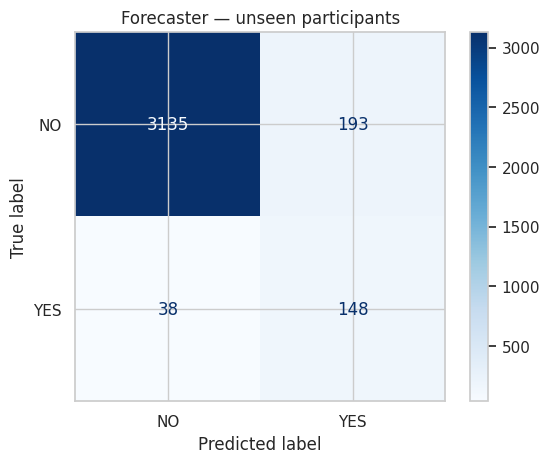

In [ ]:
def forecast_rule_score(frame):
    warning=(frame.current_state=='WARNING').astype(float)
    return np.clip(
        0.02 + 0.26*warning
        + 0.18*np.clip(frame.rssi_slope_dbm_per_s.fillna(0).clip(lower=0)/5.0,0,1)
        + 0.15*np.clip((frame.rssi_last_dbm.fillna(-95)+90)/40,0,1)*frame.hazard_active_now
        + 0.13*frame.sudden_motion
        + 0.10*np.clip(frame.current_warning_duration_seconds/8,0,1)
        + 0.08*np.clip(frame.repeated_exposure_count/4,0,1)
        + 0.08*np.clip(frame.mq135_relative_change_pct.fillna(0).clip(lower=0)/120,0,1),
        0,0.98,
    ).to_numpy(float)

rule_val_prob=forecast_rule_score(forecast_val)
rule_threshold,_=tune_threshold(yf_val,rule_val_prob,precision_floor=0.20)

# Final evaluation model is trained only on outer training participants. Test remains untouched.
Xf_train_all=forecast_train_all[FORECAST_FEATURES]
yf_train_all=forecast_train_all[FORECAST_TARGET].astype(int)
gf_train_all=forecast_train_all.participant_id
outer_splits=list(StratifiedGroupKFold(n_splits=5,shuffle=True,random_state=SEED+2).split(Xf_train_all,yf_train_all,gf_train_all))
forecast_final=CalibratedClassifierCV(estimator=clone(selected_template),method='sigmoid',cv=outer_splits).fit(Xf_train_all,yf_train_all)
test_prob=forecast_final.predict_proba(Xf_test)[:,1]
rule_test_prob=forecast_rule_score(forecast_test)

forecast_test_metrics=binary_metrics(yf_test,test_prob,forecast_threshold)
rule_test_metrics=binary_metrics(yf_test,rule_test_prob,rule_threshold)
display(pd.DataFrame([
    {'model':'rule_baseline',**rule_test_metrics},
    {'model':FORECAST_SELECTED+'_calibrated',**forecast_test_metrics},
]).drop(columns='confusion_matrix').set_index('model'))

test_pred=(test_prob>=forecast_threshold).astype(int)
print(classification_report(yf_test,test_pred,target_names=['NO_FUTURE_DANGER','DANGER_WITHIN_3S'],zero_division=0))
ConfusionMatrixDisplay.from_predictions(yf_test,test_pred,display_labels=['NO','YES'],cmap='Blues'); plt.title('Forecaster — unseen participants'); plt.show()

## A3. Scenario audit, lead time, dan feature importance

In [ ]:
audit=forecast_test[['scenario_id',FORECAST_TARGET,'time_to_danger_seconds']].copy()
audit['probability']=test_prob
audit['prediction']=test_pred
rows=[]
for scenario,g in audit.groupby('scenario_id'):
    rows.append({
        'scenario':scenario,'rows':len(g),'positive_rate':g[FORECAST_TARGET].mean(),
        'precision':precision_score(g[FORECAST_TARGET],g.prediction,zero_division=0),
        'recall':recall_score(g[FORECAST_TARGET],g.prediction,zero_division=0),
        'f2':fbeta_score(g[FORECAST_TARGET],g.prediction,beta=2,zero_division=0),
    })
scenario_audit=pd.DataFrame(rows).sort_values('f2')
display(scenario_audit)

tp_lead=audit.loc[(audit[FORECAST_TARGET]==1)&(audit.prediction==1),'time_to_danger_seconds']
print('Median correct-warning lead time (seconds):',round(float(tp_lead.median()),3) if len(tp_lead) else 'n/a')
print('Missed-warning rate:',round(1-forecast_test_metrics['recall'],4))

sample=forecast_test.sample(min(2500,len(forecast_test)),random_state=SEED)
importance=permutation_importance(forecast_final,sample[FORECAST_FEATURES],sample[FORECAST_TARGET],scoring=f2_scorer,n_repeats=3,random_state=SEED,n_jobs=-1)
forecast_importance=pd.DataFrame({'feature':FORECAST_FEATURES,'importance':importance.importances_mean}).sort_values('importance',ascending=False)
display(forecast_importance.head(15))

,scenario,rows,positive_rate,precision,recall,f2
1,BLE_PACKET_LOSS,277,0.000000,0.000000,0.000000,0.000000
2,FALL_CANDIDATE,99,0.000000,0.000000,0.000000,0.000000
6,IMPACT_CANDIDATE,114,0.000000,0.000000,0.000000,0.000000
5,HAZARD_INACTIVE,316,0.000000,0.000000,0.000000,0.000000
7,NORMAL_PASSAGE,622,0.000000,0.000000,0.000000,0.000000
8,NORMAL_WORK_NEAR_MACHINE,562,0.000000,0.000000,0.000000,0.000000
11,RSSI_FLUCTUATION,369,0.000000,0.000000,0.000000,0.000000
12,SUDDEN_MOTION_AFTER_WARNING,204,0.078431,0.141176,0.750000,0.402685
10,REPEATED_EXPOSURE,217,0.248848,0.548387,0.629630,0.611511
9,PROLONGED_DANGER,44,0.454545,0.857143,0.600000,0.638298


Median correct-warning lead time (seconds): 1.3
Missed-warning rate: 0.2043


,feature,importance
27,current_state,0.333017
26,repeated_exposure_count,0.189996
29,hazard_type,0.164703
8,rssi_last_dbm,0.113722
24,hazard_active_now,0.075003
23,mq135_relative_change_pct,0.065334
6,rssi_std_db,0.036265
18,orientation_change_deg,0.024068
28,sensor_health_status,0.023131
2,rssi_valid_ratio,0.017043


# Part B — AI Priority Engine

## B1. Participant holdout, rule baseline, dan grouped model selection

In [ ]:
priority_train, priority_test=group_holdout(priority_df,PRIORITY_TARGET,test_size=0.25,seed=SEED)
Xp_train=priority_train[PRIORITY_FEATURES]; yp_train=priority_train[PRIORITY_TARGET]
Xp_test=priority_test[PRIORITY_FEATURES]; yp_test=priority_test[PRIORITY_TARGET]
gp_train=priority_train.participant_id

def priority_rule_score(frame):
    return np.clip(
        8
        + 18*np.clip((frame.rssi_peak_dbm+90)/42,0,1)*frame.hazard_active
        + 12*np.clip(frame.danger_duration_seconds/6,0,1)
        + 15*frame.candidate_impact + 13*frame.candidate_fall
        + 7*np.clip(frame.post_event_stillness_seconds.fillna(0)/7,0,1)
        + 7*np.clip(frame.repeated_exposure_count/5,0,1)
        + 5*(1-frame.local_warning_success)
        + 8*np.clip(frame.mq135_relative_change_pct.fillna(0).clip(lower=45)/110,0,1),0,100,
    ).to_numpy(float)

def priority_from_score(score):
    return np.where(score>=53,'HIGH',np.where(score>=31,'MEDIUM','LOW'))

rule_priority_pred=priority_from_score(priority_rule_score(priority_test))

priority_models=candidates(PRIORITY_NUMERIC,PRIORITY_CATEGORICAL)
pcv=StratifiedGroupKFold(n_splits=5,shuffle=True,random_state=SEED)
pcv_splits=list(pcv.split(Xp_train,yp_train,gp_train))
rows=[]
for name,estimator in priority_models.items():
    scores=cross_validate(estimator,Xp_train,yp_train,cv=pcv_splits,scoring={'f1_macro':'f1_macro','recall_macro':'recall_macro','accuracy':'accuracy'},n_jobs=-1)
    rows.append({'model':name,'f1_macro':scores['test_f1_macro'].mean(),'recall_macro':scores['test_recall_macro'].mean(),'accuracy':scores['test_accuracy'].mean(),'f1_macro_std':scores['test_f1_macro'].std()})
priority_cv=pd.DataFrame(rows).sort_values('f1_macro',ascending=False).reset_index(drop=True)
display(priority_cv)
PRIORITY_SELECTED=str(priority_cv.iloc[0].model)
print('Selected:',PRIORITY_SELECTED)

,model,f1_macro,recall_macro,accuracy,f1_macro_std
0,random_forest,0.757406,0.751087,0.774914,0.014561
1,logistic_regression,0.719820,0.762450,0.757286,0.003883


Selected: random_forest


## B2. Untouched participant test

,accuracy,precision_macro,recall_macro,f1_macro,high_precision,high_recall
model,,,,,,
rule_baseline,0.785333,0.816466,0.68877,0.723689,0.870370,0.431193
random_forest,0.784667,0.785662,0.75698,0.767454,0.778947,0.678899


              precision    recall  f1-score   support

         LOW       0.87      0.76      0.81       761
      MEDIUM       0.71      0.83      0.76       630
        HIGH       0.78      0.68      0.73       109

    accuracy                           0.78      1500
   macro avg       0.79      0.76      0.77      1500
weighted avg       0.80      0.78      0.79      1500



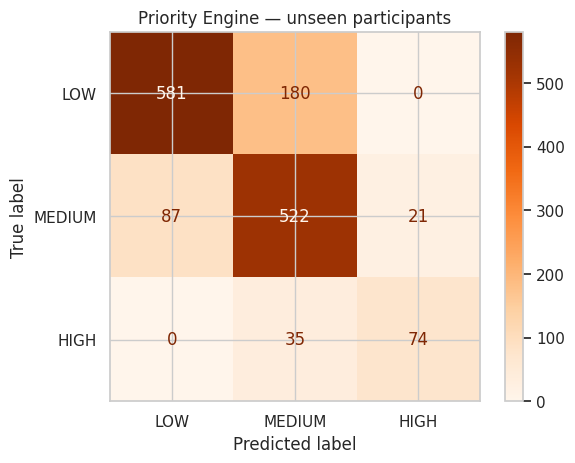

In [ ]:
priority_model=clone(priority_models[PRIORITY_SELECTED]).fit(Xp_train,yp_train)
priority_pred=priority_model.predict(Xp_test)

def multi_metrics(y,pred):
    return {
        'accuracy':accuracy_score(y,pred),
        'precision_macro':precision_score(y,pred,average='macro',zero_division=0),
        'recall_macro':recall_score(y,pred,average='macro',zero_division=0),
        'f1_macro':f1_score(y,pred,average='macro',zero_division=0),
        'high_precision':precision_score(y,pred,labels=['HIGH'],average='macro',zero_division=0),
        'high_recall':recall_score(y,pred,labels=['HIGH'],average='macro',zero_division=0),
    }

priority_metrics=multi_metrics(yp_test,priority_pred)
priority_rule_metrics=multi_metrics(yp_test,rule_priority_pred)
display(pd.DataFrame([
    {'model':'rule_baseline',**priority_rule_metrics},
    {'model':PRIORITY_SELECTED,**priority_metrics},
]).set_index('model'))
print(classification_report(yp_test,priority_pred,labels=['LOW','MEDIUM','HIGH'],zero_division=0))
ConfusionMatrixDisplay.from_predictions(yp_test,priority_pred,labels=['LOW','MEDIUM','HIGH'],cmap='Oranges'); plt.title('Priority Engine — unseen participants'); plt.show()

## B3. Scenario audit dan feature importance

In [ ]:
paudit=priority_test[['scenario_id',PRIORITY_TARGET]].copy(); paudit['prediction']=priority_pred
rows=[]
for scenario,g in paudit.groupby('scenario_id'):
    rows.append({'scenario':scenario,'rows':len(g),'accuracy':accuracy_score(g[PRIORITY_TARGET],g.prediction),'f1_macro':f1_score(g[PRIORITY_TARGET],g.prediction,average='macro',zero_division=0)})
display(pd.DataFrame(rows).sort_values('f1_macro'))

sample=priority_test.sample(min(2000,len(priority_test)),random_state=SEED)
pimp=permutation_importance(priority_model,sample[PRIORITY_FEATURES],sample[PRIORITY_TARGET],scoring='f1_macro',n_repeats=3,random_state=SEED,n_jobs=-1)
priority_importance=pd.DataFrame({'feature':PRIORITY_FEATURES,'importance':pimp.importances_mean}).sort_values('importance',ascending=False)
display(priority_importance.head(15))

,scenario,rows,accuracy,f1_macro
2,FALL_CANDIDATE,64,0.781250,0.297619
9,PROLONGED_DANGER,83,0.771084,0.451654
6,IMPACT_CANDIDATE,56,0.571429,0.457143
11,RSSI_FLUCTUATION,109,0.770642,0.484283
4,FORKLIFT_CROSSING,155,0.780645,0.485396
3,FORKLIFT_APPROACH,165,0.793939,0.500670
8,NORMAL_WORK_NEAR_MACHINE,198,0.803030,0.503112
1,BLE_PACKET_LOSS,84,0.797619,0.512965
0,AIR_QUALITY_DEGRADATION,68,0.779412,0.535017
10,REPEATED_EXPOSURE,102,0.784314,0.598743


,feature,importance
26,alarm_level,0.028162
8,danger_duration_seconds,0.021099
2,rssi_peak_dbm,0.020098
14,candidate_impact,0.015137
19,mq135_relative_change_pct,0.007568
16,post_event_stillness_seconds,0.005475
5,rssi_slope_dbm_per_s,0.003921
7,warning_duration_seconds,0.003795
3,rssi_min_dbm,0.003510
13,sudden_motion,0.003108


# Part C — Artifacts, safety gate, dan model card

In [ ]:
# Synthetic data can never by itself unlock real-world deployment.
forecast_beats_rule = forecast_test_metrics['f2'] > rule_test_metrics['f2']
priority_beats_rule = priority_metrics['f1_macro'] > priority_rule_metrics['f1_macro']

forecast_bundle={
    'kind':'pre_danger_forecaster_v2','estimator':forecast_final,'features':FORECAST_FEATURES,
    'threshold':forecast_threshold,'metrics':forecast_test_metrics,'rule_baseline_metrics':rule_test_metrics,
    'data_origin':'SYNTHETIC_CONTINUOUS_V2','beats_rule_on_synthetic_holdout':bool(forecast_beats_rule),
    'deployment_recommended':False,'safety_note':'Synthetic-only; run in shadow/advisory mode until real controlled validation.'
}
priority_bundle={
    'kind':'priority_engine_v2','estimator':priority_model,'features':PRIORITY_FEATURES,
    'metrics':priority_metrics,'rule_baseline_metrics':priority_rule_metrics,
    'data_origin':'SYNTHETIC_EVENT_V2','beats_rule_on_synthetic_holdout':bool(priority_beats_rule),
    'deployment_recommended':False,'safety_note':'Synthetic supervisor labels; final K3 verification remains mandatory.'
}
joblib.dump(forecast_bundle,MODEL_DIR/'near_miss_forecaster_v2_candidate.joblib')
joblib.dump(priority_bundle,MODEL_DIR/'priority_engine_v2_candidate.joblib')

model_card=f'''# REKSA AI v2 Model Card

Generated: {datetime.now(UTC).isoformat()}

## Data boundary
All metrics below come from synthetic data. They are development evidence, not real-world safety claims.

## Pre-Danger Forecaster
- Model: {FORECAST_SELECTED}
- Forecast horizon: 3 seconds after the feature cutoff
- Test prevalence: {yf_test.mean():.4f}
- Precision: {forecast_test_metrics['precision']:.4f}
- Recall: {forecast_test_metrics['recall']:.4f}
- F2: {forecast_test_metrics['f2']:.4f}
- PR-AUC: {forecast_test_metrics['average_precision']:.4f}
- ROC-AUC: {forecast_test_metrics['roc_auc']:.4f}
- Threshold selected on validation participants: {forecast_threshold:.3f}
- Beats rule baseline on synthetic F2: {forecast_beats_rule}

## Priority Engine
- Model: {PRIORITY_SELECTED}
- Macro F1: {priority_metrics['f1_macro']:.4f}
- Macro recall: {priority_metrics['recall_macro']:.4f}
- HIGH recall: {priority_metrics['high_recall']:.4f}
- Beats rule baseline on synthetic macro F1: {priority_beats_rule}

## Deployment decision
`deployment_recommended = false` for both models until controlled hardware data and supervisor-labelled real events are available. ESP32 deterministic alarms remain the primary safety layer.
'''
(MODEL_DIR/'REKSA_AI_v2_MODEL_CARD.md').write_text(model_card,encoding='utf-8')
print(model_card)

# REKSA AI v2 Model Card

Generated: 2026-08-07T12:36:06.345774+00:00

## Data boundary
All metrics below come from synthetic data. They are development evidence, not real-world safety claims.

## Pre-Danger Forecaster
- Model: logistic_regression
- Forecast horizon: 3 seconds after the feature cutoff
- Test prevalence: 0.0529
- Precision: 0.4340
- Recall: 0.7957
- F2: 0.6820
- PR-AUC: 0.6240
- ROC-AUC: 0.9487
- Threshold selected on validation participants: 0.115
- Beats rule baseline on synthetic F2: True

## Priority Engine
- Model: random_forest
- Macro F1: 0.7675
- Macro recall: 0.7570
- HIGH recall: 0.6789
- Beats rule baseline on synthetic macro F1: True

## Deployment decision
`deployment_recommended = false` for both models until controlled hardware data and supervisor-labelled real events are available. ESP32 deterministic alarms remain the primary safety layer.



## Final interpretation

- **Forecaster v2 benar-benar memakai future horizon.** Input berhenti pada `t`; label positif hanya jika onset `DANGER` terjadi setelah `t` dan maksimal 3 detik kemudian.
- **Fall/impact spontan tidak dipaksa menjadi masalah forecasting.** MPU6050 mendeteksi kandidat event saat terjadi; Priority Engine melakukan triase setelahnya.
- **Overlapping windows berasal dari trajectory kontinu.** Korelasi antar-window sekarang merupakan bagian dari audit, bukan diasumsikan.
- **Threshold tidak dipilih dari test set.** Threshold forecaster dipilih menggunakan participant validation terpisah.
- **Participant test tidak pernah terlihat saat training.** `scenario_id`, reviewer label, target metadata, IDs, dan time-to-danger tidak boleh menjadi fitur.
- **Priority Engine tetap advisory.** Label supervisor pada dataset ini sintetis; dataset nyata harus menggantinya dengan label K3/supervisor terverifikasi.
- **Jangan mengejar model lebih kompleks sebelum data nyata tersedia.** Tahap berikutnya adalah controlled capture menggunakan ESP32 + BLE + MPU6050 + DHT22 + MQ135, kemudian shadow-mode evaluation.